# Mic Input Processing


## 1. Import Required Libraries

In [ ]:
# Import libraries for audio processing, visualization, and database operations
import matplotlib.pyplot as plt
from pathlib import Path
import time
import numpy as np

from audio_processing.audio import load_audio, record_audio, lowpass_filter, highpass_filter, bandpass_filter
from audio_processing.spectrogram import spectrogram, find_peaks
from controllers.database import connect, init_db
from controllers.fingerprint import generate_fingerprints
from controllers.song_manager import persist_song_data

In [ ]:
# Record audio from the microphone
for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")
print(f"Shape of input: {y_mic.shape}")

# Debug: Check the audio levels
print(f"Audio min: {y_mic.min():.6f}, max: {y_mic.max():.6f}")
print(f"Audio mean: {y_mic.mean():.6f}, std: {y_mic.std():.6f}")

# Normalize audio before saving if levels are too low
y_mic_normalized = y_mic / np.max(np.abs(y_mic)) * 0.95  # Normalize to 95% of max int16

# Save audio to file
mic_output_file = Path("data", "assets", "mic_recordings", "mic_recording.wav")
from scipy.io.wavfile import write
write(mic_output_file.as_posix(), sr_mic, (y_mic_normalized * 32767).astype('int16'))
print(f"Saved mic recording to {mic_output_file.as_posix()}")

# Load and verify what was saved
from scipy.io.wavfile import read
sr_test, y_test = read(mic_output_file.as_posix())
print(f"Verified saved file - min: {y_test.min()}, max: {y_test.max()}")

In [ ]:
# Load original clean 0022 audio for comparison
original_file = Path("data", "assets", "clean_wavs", "music-hd-0022.wav")
y_orig, sr_orig = load_audio(original_file.as_posix())
print(f"Loaded clean audio - shape: {y_orig.shape}, sr: {sr_orig}, length in seconds: {len(y_orig) / sr_orig:.2f}")

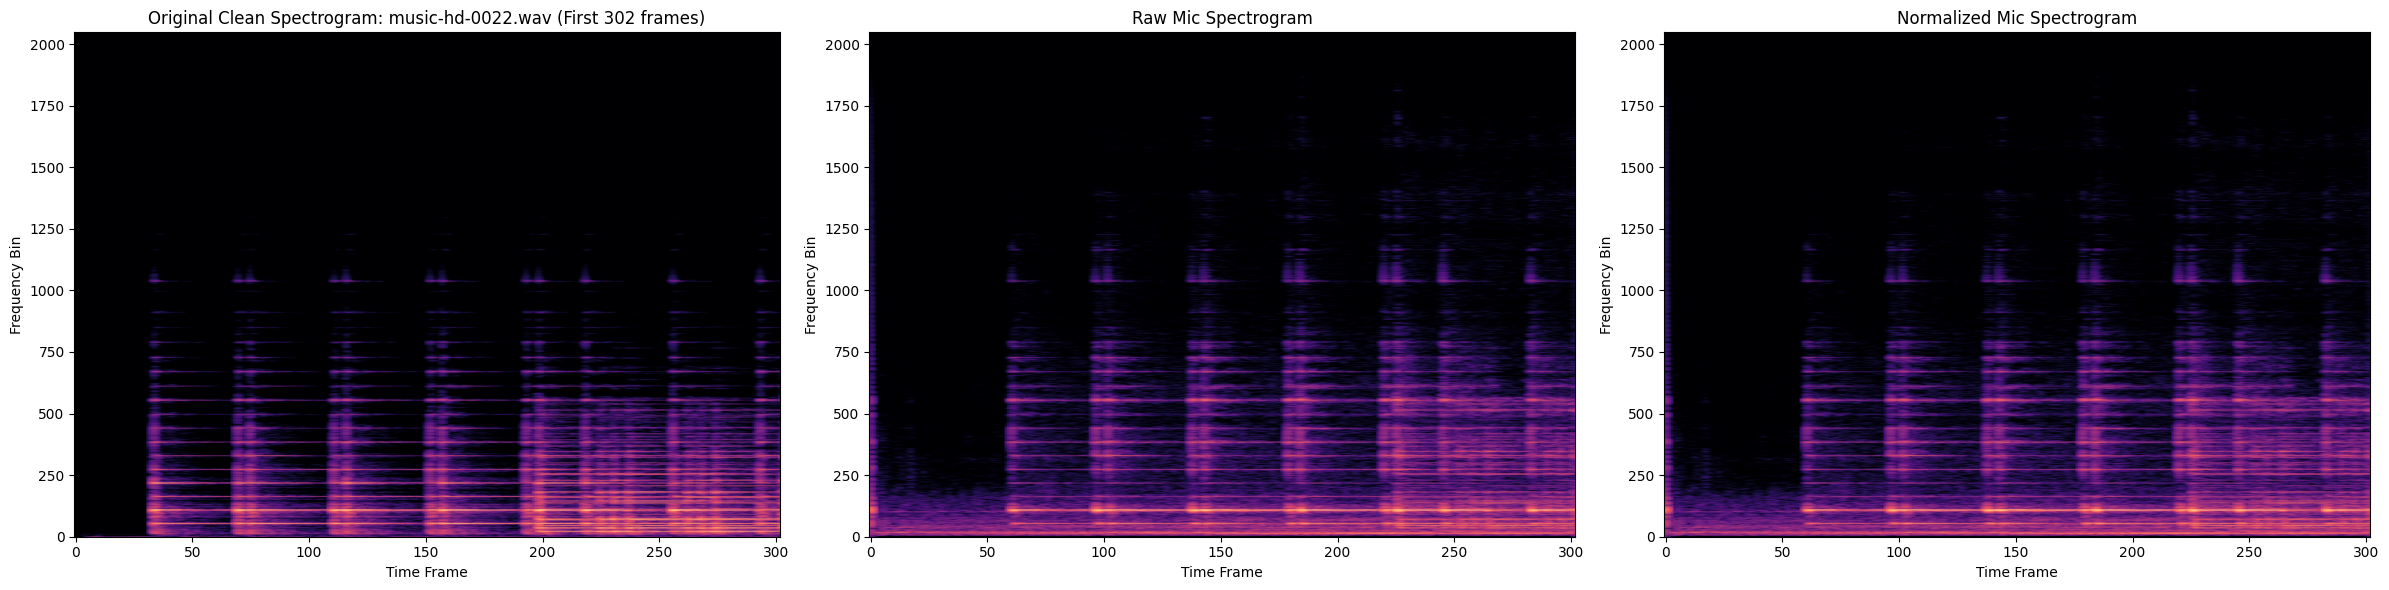

In [62]:
# Compute spectrograms
from config import DEFAULT_SR

y_mic = y_mic_normalized
S_db_orig = spectrogram(y_orig)
S_db_mic = spectrogram(y_mic)
S_db_mic_normalized = spectrogram(y_mic_normalized)

# Slice original to match mic length
mic_time_frames = S_db_mic.shape[1]
S_db_original_slice = S_db_orig[:, :mic_time_frames]

# Show side-by-side spectrograms
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Original Clean Spectrogram: {original_file.name} (First {mic_time_frames} frames)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Raw Mic Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

axes[2].imshow(S_db_mic_normalized, aspect="auto", origin="lower", cmap="magma")
axes[2].set_title("Normalized Mic Spectrogram")
axes[2].set_xlabel("Time Frame")
axes[2].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Define other variables
sr_mic = DEFAULT_SR
amp_min = -60
noise_length = int(0.5 * sr_mic)
if len(y_mic) > noise_length:
    noise_clip = y_mic[:noise_length]
else:
    noise_clip = y_mic

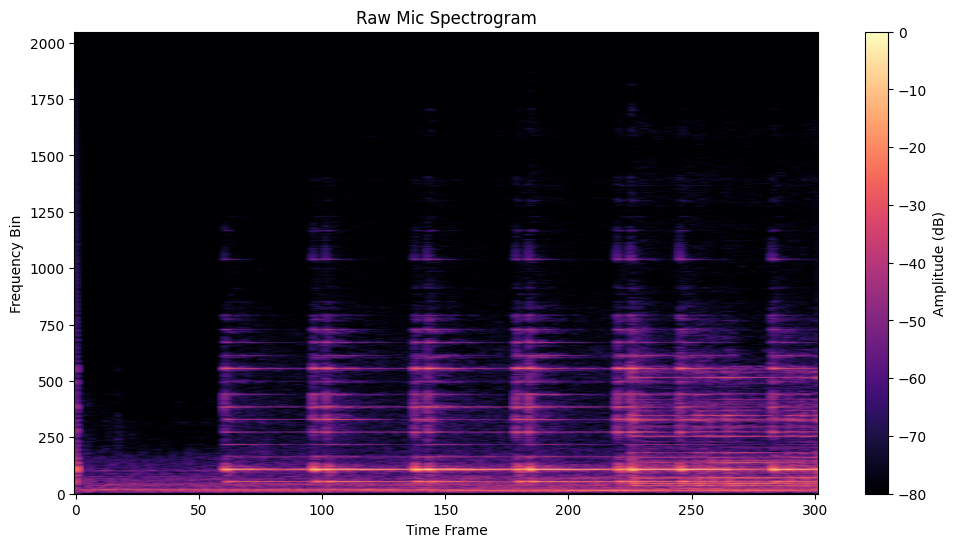

In [63]:
# 1. Raw Mic Spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

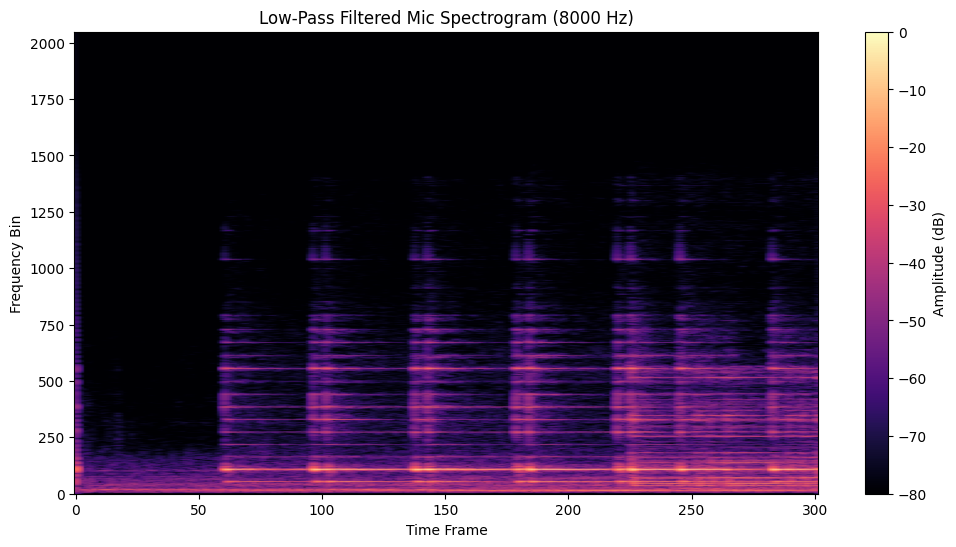

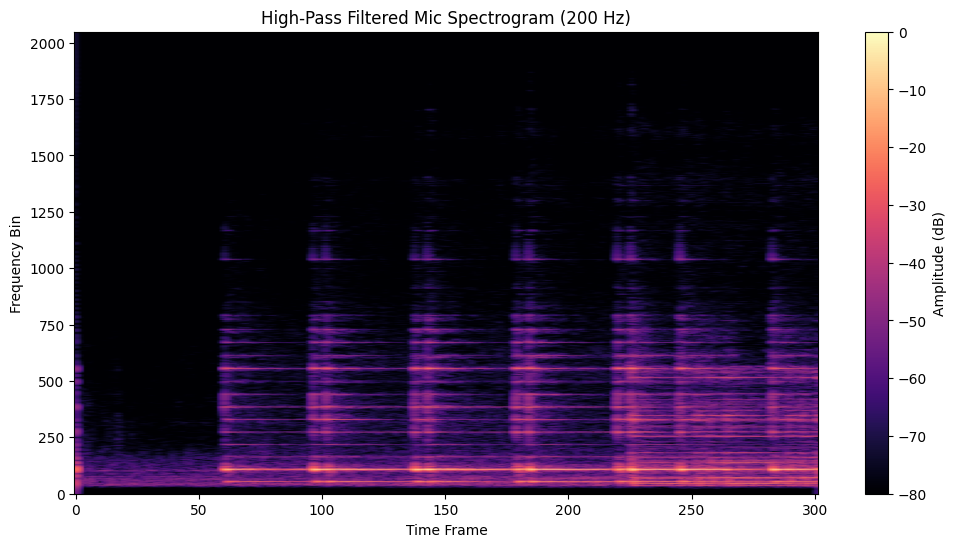

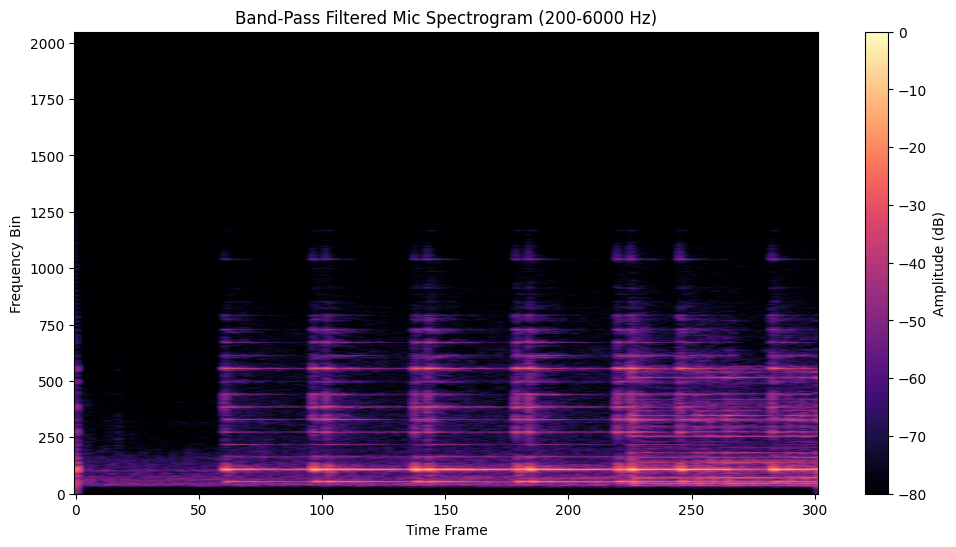

In [64]:
# 2. Low-Pass Filtered (removes high frequencies)
cutoff_low = 8000  # Hz
y_mic_lowpass = lowpass_filter(y_mic, cutoff_low, sr_mic)
S_db_mic_lowpass = spectrogram(y_mic_lowpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_lowpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Low-Pass Filtered Mic Spectrogram ({cutoff_low} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

cutoff_high = 200  # Hz
y_mic_highpass = highpass_filter(y_mic, cutoff_high, sr_mic)
S_db_mic_highpass = spectrogram(y_mic_highpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_highpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"High-Pass Filtered Mic Spectrogram ({cutoff_high} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

lowcut = 200  # Hz
highcut = 6000  # Hz
y_mic_bandpass = bandpass_filter(y_mic, lowcut, highcut, sr_mic)
S_db_mic_bandpass = spectrogram(y_mic_bandpass)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_bandpass, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Band-Pass Filtered Mic Spectrogram ({lowcut}-{highcut} Hz)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

# Overwrite bandpass with lowpass, because looking at the original audio spectrogram, doesn't seem to make sense to get rid of lower frequenceis
y_mic_chosen_pass = y_mic_lowpass

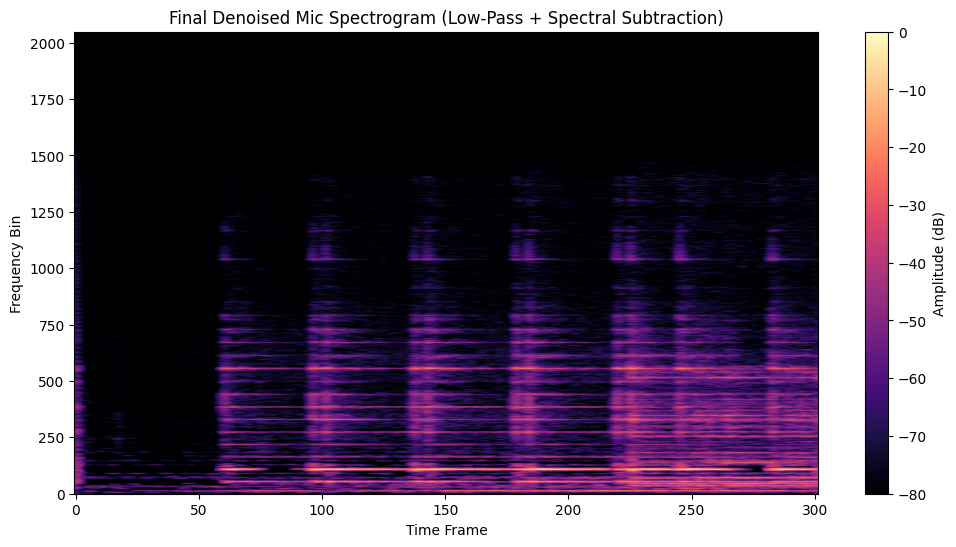

In [65]:
# 5. Spectral Subtraction (noise reduction)
import librosa
import numpy as np

default_hop_length = 512
# Using the pass filtered as base for denoising
mic_stft = librosa.stft(y_mic_chosen_pass)
noise_stft = librosa.stft(noise_clip)
noise_power = np.mean(np.abs(noise_stft)**2, axis=1)

mic_stft_denoised = mic_stft - noise_power[:, np.newaxis] * 0.5
mic_stft_denoised = np.maximum(mic_stft_denoised, 0)

y_mic_final = librosa.istft(mic_stft_denoised, hop_length=default_hop_length)
S_db_mic_final = spectrogram(y_mic_final)

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic_final, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title("Final Denoised Mic Spectrogram (Low-Pass + Spectral Subtraction)")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

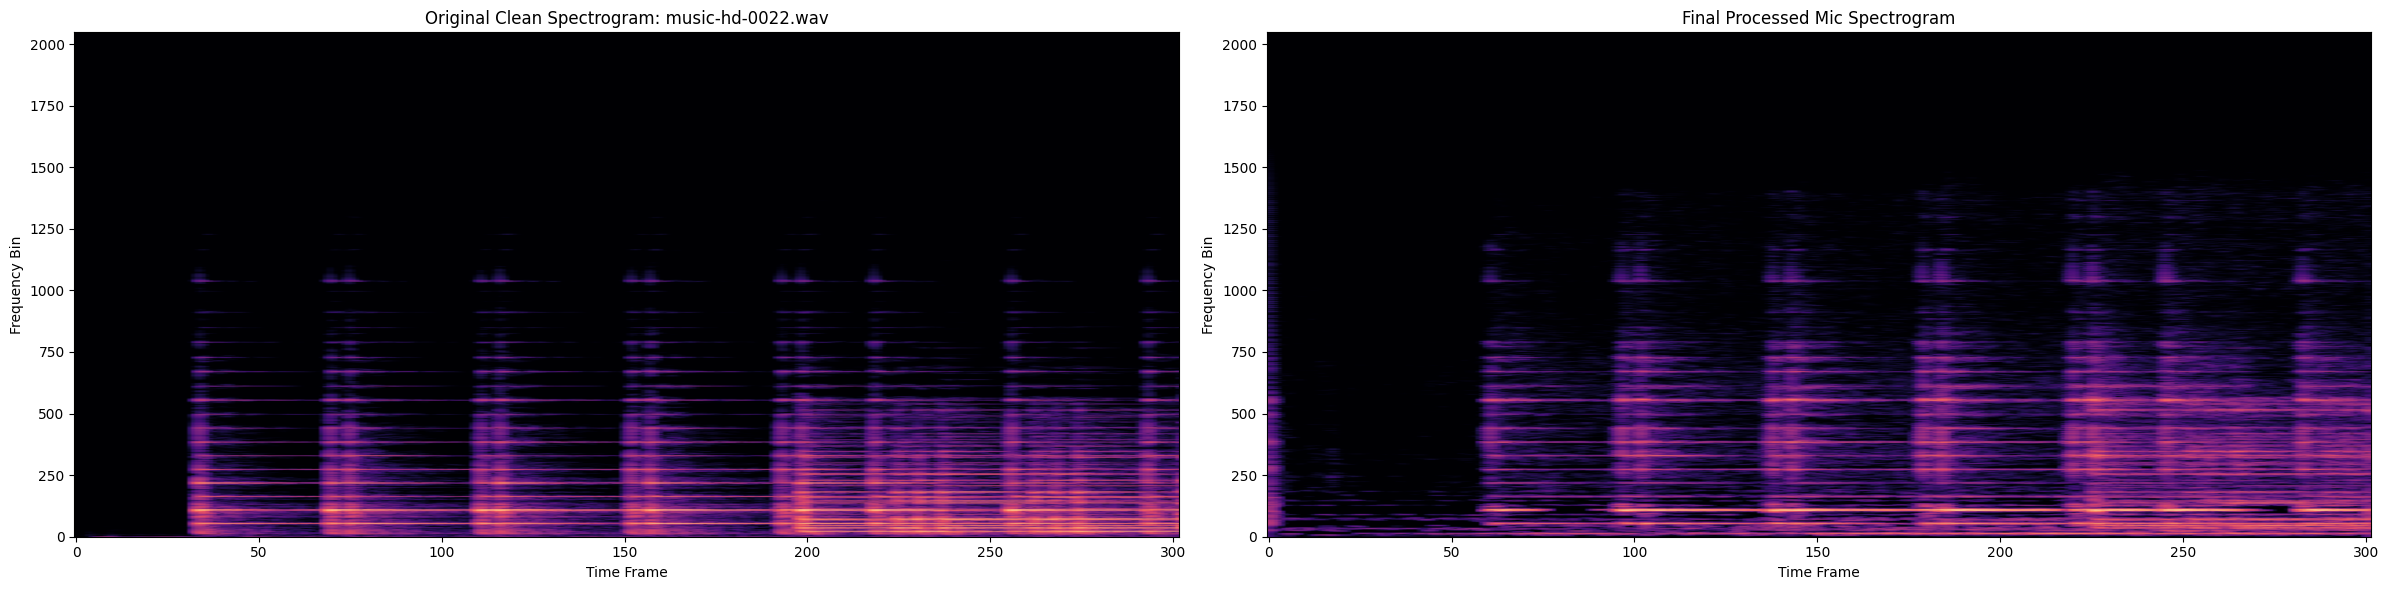

Original max dB: -5.42, Final Mic max dB: 0.00
Original min dB: -80.00, Final Mic min dB: -80.00


In [66]:
# 6. Comparison: Final Processed Mic vs. Original Clean Spectrogram
fig, axes = plt.subplots(1, 2, figsize=(24, 6))

# Original clean spectrogram (sliced)
axes[0].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(f"Original Clean Spectrogram: {original_file.name}")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

# Final processed mic spectrogram
axes[1].imshow(S_db_mic_final, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Final Processed Mic Spectrogram")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

plt.tight_layout()
plt.show()

# Print stats
print(f"Original max dB: {np.max(S_db_original_slice):.2f}, Final Mic max dB: {np.max(S_db_mic_final):.2f}")
print(f"Original min dB: {np.min(S_db_original_slice):.2f}, Final Mic min dB: {np.min(S_db_mic_final):.2f}")

Shape of original slice: (2049, 302), max dB: -5.42, min dB: -80.00
Shape of final mic slice: (2049, 302), max dB: 0.00, min dB: -80.00


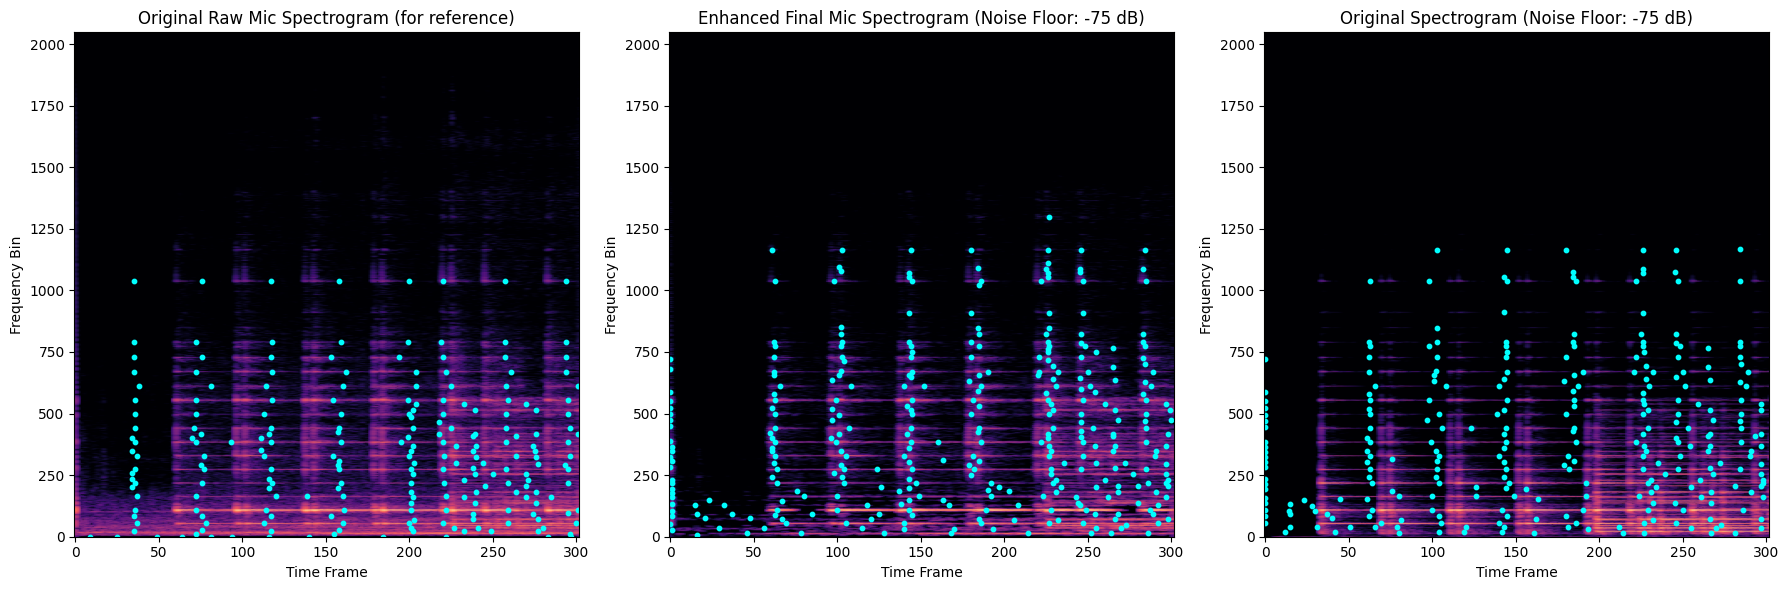

Mic raw peaks: 280
Mic enhanced peaks: 329
Original enhanced peaks: 222
Mic raw fingerprints: 1834
Mic enhanced fingerprints: 2179
Original enhanced fingerprints: 1518


In [67]:
# Enhance Peaks: Apply a noise floor to make peaks more evident by reducing background noise
noise_floor_db = -75  # dB; adjust to set the minimum level

# Apply to original
print(f"Shape of original slice: {S_db_original_slice.shape}, max dB: {np.max(S_db_original_slice):.2f}, min dB: {np.min(S_db_original_slice):.2f}")

# Apply to final processed mic
S_db_mic_enhanced = np.maximum(S_db_mic_final, noise_floor_db)
print(f"Shape of final mic slice: {S_db_mic_final.shape}, max dB: {np.max(S_db_mic_final):.2f}, min dB: {np.min(S_db_mic_final):.2f}")

# Visualize enhanced versions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(S_db_mic, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("Original Raw Mic Spectrogram (for reference)")
axes[0].set_xlabel("Time Frame")
axes[0].set_ylabel("Frequency Bin")

axes[1].imshow(S_db_mic_enhanced, aspect="auto", origin="lower", cmap="magma", vmin=noise_floor_db, vmax=np.max(S_db_mic_enhanced))
axes[1].set_title(f"Enhanced Final Mic Spectrogram (Noise Floor: {noise_floor_db} dB)")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel("Frequency Bin")

axes[2].imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="magma", vmin=noise_floor_db, vmax=np.max(S_db_original_slice))
axes[2].set_title(f"Original Spectrogram (Noise Floor: {noise_floor_db} dB)")
axes[2].set_xlabel("Time Frame")
axes[2].set_ylabel("Frequency Bin")

peaks_original_enhanced = find_peaks(S_db_original_slice, amp_min=amp_min)
peaks_mic_enhanced = find_peaks(S_db_mic_enhanced, amp_min=amp_min)
peaks_mic_raw = find_peaks(S_db_mic, amp_min=amp_min)

times, freqs = zip(*peaks_original_enhanced)
axes[0].scatter(times, freqs, s=10, c="cyan", label="Peaks")
times, freqs = zip(*peaks_mic_enhanced)
axes[1].scatter(times, freqs, s=10, c="cyan", label="Peaks")
times, freqs = zip(*peaks_mic_raw)
axes[2].scatter(times, freqs, s=10, c="cyan", label="Peaks")



plt.tight_layout()
plt.show()

fps_mic_raw = generate_fingerprints(peaks_mic_raw)
fps_mic_enhanced = generate_fingerprints(peaks_mic_enhanced)
fps_original_enhanced = generate_fingerprints(peaks_original_enhanced)

print(f"Mic raw peaks: {len(peaks_mic_raw)}")
print(f"Mic enhanced peaks: {len(peaks_mic_enhanced)}")
print(f"Original enhanced peaks: {len(peaks_original_enhanced)}")

print(f"Mic raw fingerprints: {len(fps_mic_raw)}")
print(f"Mic enhanced fingerprints: {len(fps_mic_enhanced)}")
print(f"Original enhanced fingerprints: {len(fps_original_enhanced)}")


In [83]:
# Load songs to database
clean_folder = Path("data", "assets", "clean_wavs")
song_ids = []
conn = connect()
init_db(conn)
print("Adding songs to DB...")
for wav_path in clean_folder.glob("*.wav"):
    y, sr = load_audio(wav_path.as_posix())
    S_db = spectrogram(y)
    peaks = find_peaks(S_db)
    fps = generate_fingerprints(peaks)
    persist_song_data(conn, wav_path.stem, fps)
    song_ids.append(wav_path.stem)
    print(f"Added {wav_path.stem}, {len(fps)} fingerprints")

Adding songs to DB...
Added music-hd-0022, 19438 fingerprints
Added music-hd-0023, 27190 fingerprints
Added music-hd-0001, 22951 fingerprints
Added music-hd-0002, 10934 fingerprints


In [84]:
from audio_processing.spectrogram import frame_to_seconds
import controllers.match_service as match_service
match_service = match_service.MatchService()
conn = connect()
init_db(conn)
match_service.conn = conn

print(f"ENHANCED SPECTROGRAM:")
match_for_enhanced, offset_histogram_for_enhanced  = match_service.match_fingerprints(fps_mic_enhanced)

print("-"*100)
print(f"\nRAW SPECTROGRAM:")
match_for_raw, offset_histogram_for_raw = match_service.match_fingerprints(fps_mic_raw)


ENHANCED SPECTROGRAM:


Recognizing audio from 2179 fingerprints...

Total songs in DB: 4

Best match was: music-hd-0022 with score 58

----------------------------------------------------------------------------------------------------

RAW SPECTROGRAM:


Recognizing audio from 1834 fingerprints...

Total songs in DB: 4

Best match was: music-hd-0022 with score 46

 - The offset time frame with the most matches is: -27 with 58 matches, which should match -0.626938775510204 seconds
 - The maximum offset time frame is: 6799 with 3 matches, which should match 157.8724716553288 seconds
 - The minimum offset time frame is: -150 with 1 matches, which should match -3.4829931972789114 seconds
Top offsets by count: [(np.int64(-27), 58), (np.int64(-28), 17), (np.int64(4653), 6), (np.int64(4740), 4), (np.int64(5509), 4)]
Sum of top 3 offset counts: 81


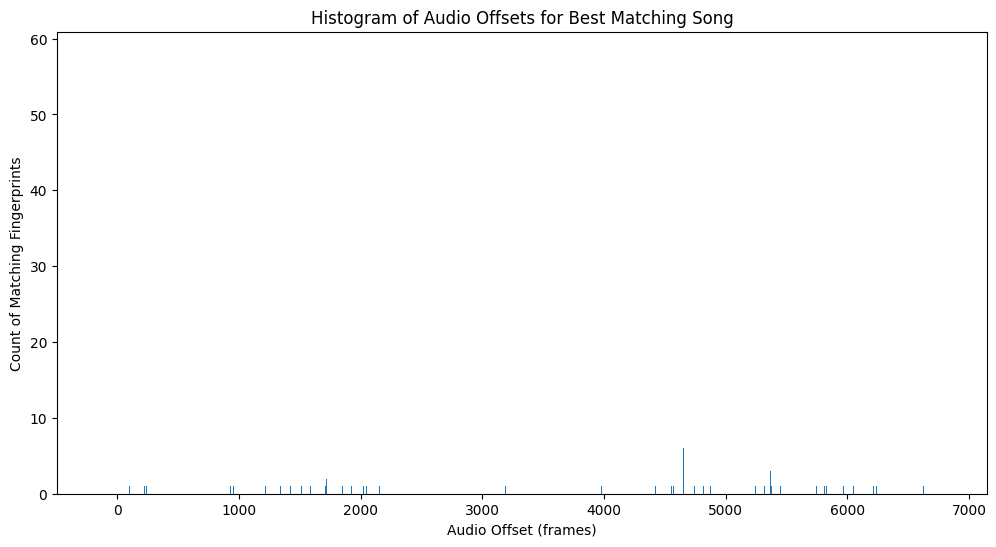

In [87]:
chosen_audio_offset_histogram = offset_histogram_for_enhanced if match_for_enhanced[1] > match_for_raw[1] else offset_histogram_for_raw

# Find the most common offset (by count, not by value)
most_common_offset = max(chosen_audio_offset_histogram.items(), key=lambda x: x[1])[0]
most_common_offset_seconds = frame_to_seconds(most_common_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The offset time frame with the most matches is: {most_common_offset} with {chosen_audio_offset_histogram[most_common_offset]} matches, which should match {most_common_offset_seconds} seconds")

max_offset = max(chosen_audio_offset_histogram.keys())
max_offset_seconds = frame_to_seconds(max_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The maximum offset time frame is: {max_offset} with {chosen_audio_offset_histogram[max_offset]} matches, which should match {max_offset_seconds} seconds")

min_offset = min(chosen_audio_offset_histogram.keys())
min_offset_seconds = frame_to_seconds(min_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The minimum offset time frame is: {min_offset} with {chosen_audio_offset_histogram[min_offset]} matches, which should match {min_offset_seconds} seconds")


# Show the top 5 offsets by count
sorted_offsets = sorted(chosen_audio_offset_histogram.items(), key=lambda x: x[1], reverse=True)
print("Top offsets by count:", sorted_offsets[:5])

top_three_offsets = sorted_offsets[:3]

# Total count of matched fingerprints within the top 3 most common offsets
sum_of_top_three = sum(count for offset, count in top_three_offsets)
print(f"Sum of top 3 offset counts: {sum_of_top_three}")

plt.figure(figsize=(12, 6))
plt.bar([offset for offset, count in sorted_offsets],
        [count for offset, count in sorted_offsets])
plt.title("Histogram of Audio Offsets for Best Matching Song")
plt.xlabel("Audio Offset (frames)")
plt.ylabel("Count of Matching Fingerprints")
plt.show()

[('032999e6a67e0ed5da6d', 1755, 441, 1779, 441), ('032999e6a67e0ed5da6d', 5008, 441, 5032, 441), ('073f3c92fe2fce065a56', 4561, 497, 4701, 497), ('08cc84cef3f540dd97ef', 357, 164, 426, 164), ('08cc84cef3f540dd97ef', 4561, 164, 4630, 164), ('0ae154efa33c1c16cb03', 4814, 612, 4856, 612), ('0ccf11b6402bc76a66e4', 6755, 555, 6859, 555), ('0d72d3ce0b7bded7b485', 1374, 219, 1431, 219), ('0d72d3ce0b7bded7b485', 1569, 219, 1626, 219), ('0d72d3ce0b7bded7b485', 1702, 219, 1759, 219), ('0d72d3ce0b7bded7b485', 1967, 219, 2024, 219), ('0d72d3ce0b7bded7b485', 2024, 219, 2081, 219), ('0d72d3ce0b7bded7b485', 4819, 219, 4876, 219), ('0d72d3ce0b7bded7b485', 4950, 219, 5007, 219), ('0d72d3ce0b7bded7b485', 6197, 219, 6254, 219), ('0db49c5d154a6a1914c6', 162, 670, 204, 670), ('0db49c5d154a6a1914c6', 6881, 670, 6923, 670), ('10d306cb366b25b0b43e', 257, 1038, 345, 1038), ('10e4f5c1f01dd566f2b0', 36, 555, 72, 555), ('10e4f5c1f01dd566f2b0', 118, 555, 154, 555), ('10e4f5c1f01dd566f2b0', 259, 555, 295, 555), ('1

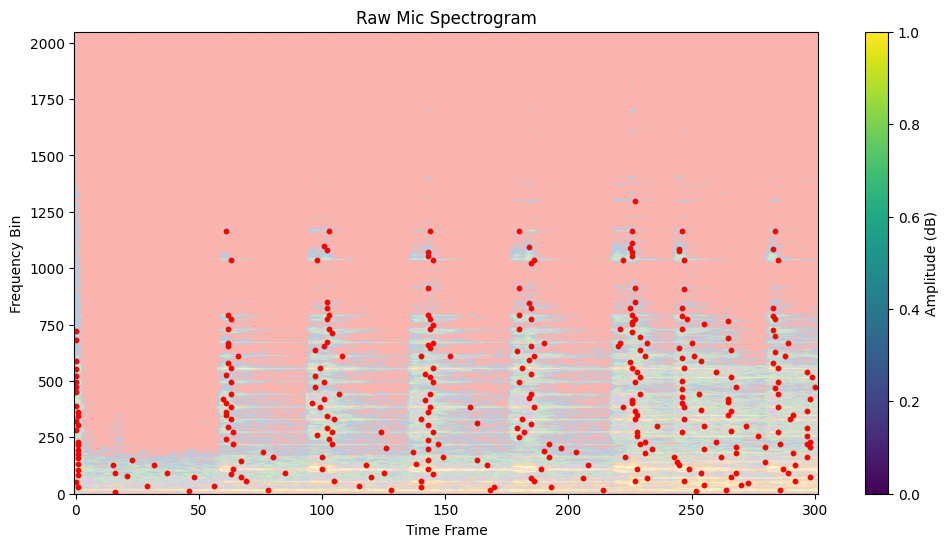

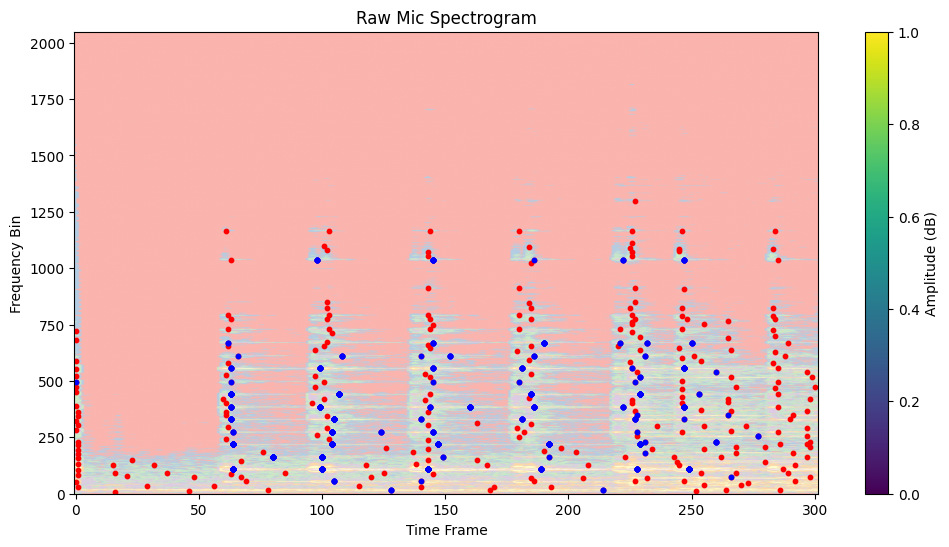

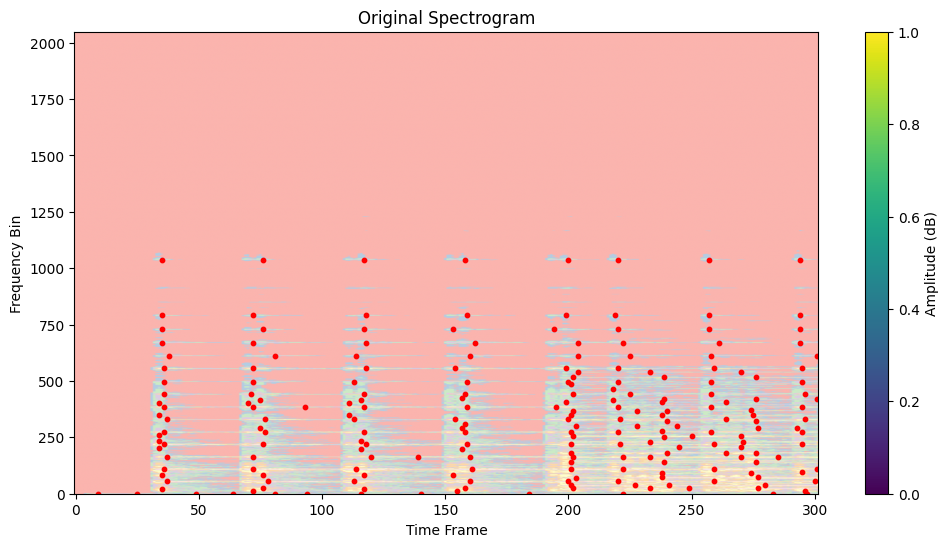

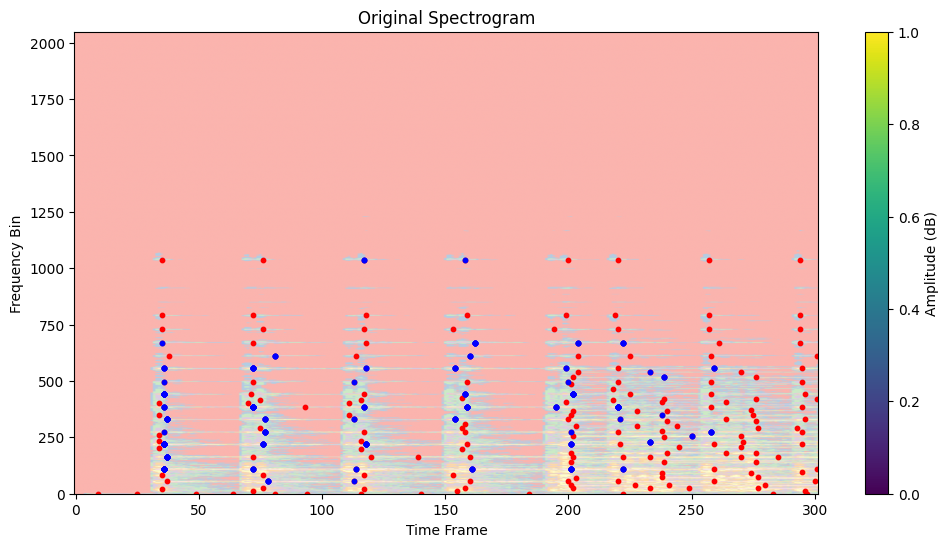

In [86]:

# get matched fingerprint times for enhanced and plot on spectrogram
mic_and_audio_fps_intersection = match_service.get_matching_fingerprints_in_song("music-hd-0022", fps_mic_enhanced)

print(mic_and_audio_fps_intersection)
hash_to_time_enhanced = {hash: (t1, f1, t2, f2) for hash, t1, f1, t2, f2 in fps_mic_enhanced}
print(hash_to_time_enhanced)
hash_to_time_original = {hash: (t1, f1, t2, f2) for hash, t1, f1, t2, f2 in fps_original_enhanced}
print(f"Number of matching fingerprints in enhanced: {len(mic_and_audio_fps_intersection)}")
print("n of hashed fingerprints in mic enhanced:", len(hash_to_time_enhanced))

coordinates_of_peaks_that_matched = [hash_to_time_enhanced[hash][:2] for hash, _, _, _, _ in mic_and_audio_fps_intersection if hash in hash_to_time_enhanced]
print(coordinates_of_peaks_that_matched)
coordinates_of_peaks_in_original = [hash_to_time_original[hash][:2] for hash, _, _, _, _  in mic_and_audio_fps_intersection if hash in hash_to_time_original]


plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*peaks_mic_enhanced), s=10, c="red", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_db_mic, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*peaks_mic_enhanced), s=10, c="red", label="Peaks")
plt.scatter(*zip(*coordinates_of_peaks_that_matched), s=10, c="blue", label="Matches")
plt.colorbar(label="Amplitude (dB)")
plt.title("Raw Mic Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*peaks_original_enhanced), s=10, c="red", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title("Original Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(S_db_original_slice, aspect="auto", origin="lower", cmap="Pastel1")
plt.scatter(*zip(*peaks_original_enhanced), s=10, c="red", label="Peaks")
plt.scatter(*zip(*coordinates_of_peaks_in_original), s=10, c="blue", label="Matches")
plt.colorbar(label="Amplitude (dB)")
plt.title("Original Spectrogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()